# Модуль 1-2
Введение, построение графиков

In [2]:
import scipy

scipy.stats.distributions.poisson.pmf(5, 4.5)

0.17082685848611215

## 1/10   Введение

## Задание 1.10

В интернет-магазине среднее время между покупками одного пользователя составляет $5$ дней. Если пользователь не сделал покупку за первые $7$ дней, какова вероятность того, что он сделает покупку в течение последующих $3$ дней? Ответ округлите до трех знаков после разделителя.

In [3]:
import math

def get_factorial(number):
    if number <= 1:
        return 1
    else:
        return get_factorial(number - 1) * number

In [4]:
lambda_value = 1 / 5
days = 3
p_days = lambda_value ** days / get_factorial(days) * math.exp(-lambda_value)
1 - p_days

0.998908358995896

In [5]:
import math

# Параметры
mean_time = 5  # среднее время между покупками в днях
lambda_param = 1 / mean_time  # параметр экспоненциального распределения

# Время, за которое нужно найти вероятность (после 7 дней без покупок)
t = 3

# Вероятность P(T <= 3) для экспоненциального распределения
probability = 1 - math.exp(-lambda_param * t)

print(f"Среднее время между покупками: {mean_time} дней")
print(f"Параметр λ: {lambda_param:.3f}")
print(f"Вероятность покупки в течение {t} дней: {probability:.6f}")
print(f"Ответ (округлено до 3 знаков): {probability:.3f}")

Среднее время между покупками: 5 дней
Параметр λ: 0.200
Вероятность покупки в течение 3 дней: 0.451188
Ответ (округлено до 3 знаков): 0.451


In [6]:
# Альтернативная версия с использованием scipy
from scipy.stats import expon

# Параметры (в scipy scale = 1/λ = mean)
probability_scipy = expon.cdf(t, scale=mean_time)

print(f"Проверка через scipy: {probability_scipy:.6f}")
print(f"Округлённый ответ: {probability_scipy:.3f}")

Проверка через scipy: 0.451188
Округлённый ответ: 0.451


## 3/10   Основные распределения случайных величин

## Дискретное равномерное распределение

$M\xi = \frac{a_1 + a_2 + … + a_n}{n}\Leftrightarrow \frac{n+1}{2}$

$D\xi = \frac{(a_1 - M\xi)^2 + \dots + (a_n - M\xi)^2}{n}\Leftrightarrow \frac{n^2-1}{12}$

## Ширина пика на половине высоты (FWHM)

В случае нормального распределения, определяемого выражением:

$f(x) = \frac{1}{\sigma \sqrt{2 \pi} } \exp \left[ -\frac{(x-x_0)^2}{2 \sigma^2} \right]\,$

где $\sigma$ — стандартное отклонение, $x_0$ — медиана, высота максимума равна $\frac{1}{\sigma \sqrt{2 \pi} },$ а полуширина выражается через стандартное отклонение следующим образом:

$\mathrm{FWHM} =   2 \sqrt{2 \ln 2 } \; \sigma \approx 2{,}355 \; \sigma$.

(array([0.11984801, 0.23969601, 0.31160482, 0.67114884, 0.93481446,
        1.39023688, 1.51008489, 2.13329453, 2.27711214, 2.51680815,
        2.25314254, 2.08535533, 1.89359852, 1.41420649, 1.27038888,
        0.69511844, 0.64717924, 0.50336163, 0.26366562, 0.43145283,
        0.16778721, 0.09587841, 0.0239696 , 0.0479392 , 0.0479392 ,
        0.        , 0.        , 0.        , 0.        , 0.0239696 ]),
 array([0.56340961, 0.60512912, 0.64684863, 0.68856814, 0.73028765,
        0.77200716, 0.81372666, 0.85544617, 0.89716568, 0.93888519,
        0.9806047 , 1.02232421, 1.06404372, 1.10576323, 1.14748274,
        1.18920224, 1.23092175, 1.27264126, 1.31436077, 1.35608028,
        1.39779979, 1.4395193 , 1.48123881, 1.52295831, 1.56467782,
        1.60639733, 1.64811684, 1.68983635, 1.73155586, 1.77327537,
        1.81499488]),
 <BarContainer object of 30 artists>)

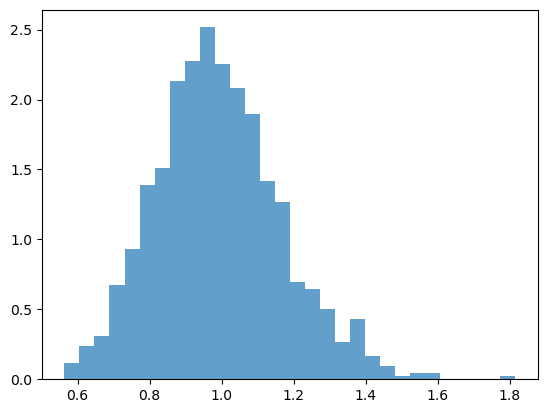

In [7]:
# Пример: Эмпирическая проверка ЦПТ
import numpy as np
import matplotlib.pyplot as plt
means = [np.mean(np.random.exponential(scale=1.0, size=30)) for _ in range(1000)]
plt.hist(means, bins=30, density=True, alpha=0.7)
# Наложить нормальную кривую с параметрами, предсказанными ЦПТ

In [8]:
import numpy as np
from scipy.stats import norm

# Параметры распределения
mu = 4
sigma = 1
threshold = 4.5

# Z-оценка
z = (threshold - mu) / sigma

# Вероятность P(Z > z)
prob = 1 - norm.cdf(z)

# Процент студентов
percent = prob * 100

# Округление до двух знаков после запятой
percent_rounded = round(percent, 2)

print(f"Z-оценка для балла {threshold}: {z:.2f}")
print(f"Вероятность балла > {threshold}: {prob:.5f}")
print(f"Процент студентов с баллом > {threshold}: {percent_rounded:.2f}%")

Z-оценка для балла 4.5: 0.50
Вероятность балла > 4.5: 0.30854
Процент студентов с баллом > 4.5: 30.85%


Точная P(S ≤ 35) = 0.8839
Приближенная P(S ≤ 35) = 0.0480
Ошибка: 0.8359


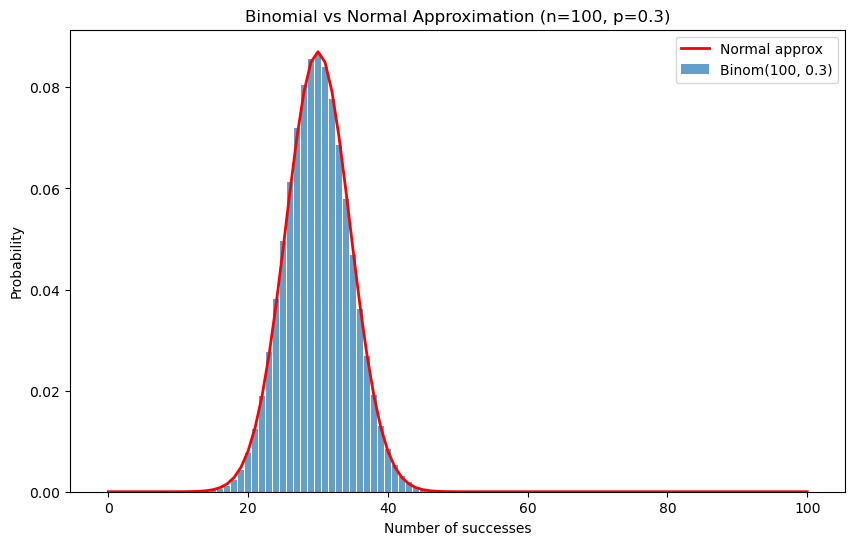

In [1]:
import numpy as np
from scipy.stats import norm, binom
import matplotlib.pyplot as plt

# Параметры
n = 100
p = 0.3
k_values = np.arange(0, n+1)

# Точное биномиальное распределение
exact_probs = binom.pmf(k_values, n, p)

# Нормальное приближение (без поправки)
mu = n * p
sigma = np.sqrt(n * p * (1 - p))
normal_approx = norm.pdf(k_values, mu, sigma)

# С поправкой на непрерывность (для кумулятивных вероятностей)
k = 35
exact_cdf = binom.cdf(k, n, p)
approx_cdf = norm.cdf(k + 0.5, mu, sigma) - norm.cdf(k - 0.5, mu, sigma)

print(f"Точная P(S ≤ {k}) = {exact_cdf:.4f}")
print(f"Приближенная P(S ≤ {k}) = {approx_cdf:.4f}")
print(f"Ошибка: {abs(exact_cdf - approx_cdf):.4f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.bar(k_values, exact_probs, alpha=0.7, label=f'Binom({n}, {p})', width=0.8)
plt.plot(k_values, normal_approx, 'r-', linewidth=2, label='Normal approx')
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.legend()
plt.title(f'Binomial vs Normal Approximation (n={n}, p={p})')
plt.show()

## 5/10 основные понятия

In [1]:
import numpy as np
from scipy import stats

# Вычисление моментов для набора данных
data = np.random.normal(0, 1, 1000)

mean = np.mean(data)           # a1
variance = np.var(data)        # m2 (смещенная)
skewness = stats.skew(data)    # g1
kurtosis = stats.kurtosis(data)# g2

In [14]:
import numpy as np

# Выборка
sample = [1.5, 1.7, 2.1, 2.1, 3.0]
sample = [1.5, 2, 2.5]
sample = [-2, -1,-1,0,0,1,1,2,3,3,]
x = np.array(sample)

n = len(x)

# 1. Начальные моменты
a1 = np.mean(x)
a2 = np.mean(x**2)
a3 = np.mean(x**3)

# 2. Центральные моменты
m2 = np.mean((x - a1)**2)
m3 = np.mean((x - a1)**3)
m4 = np.mean((x - a1)**4)

# 3. Коэффициенты
s = np.sqrt(m2)
skew = m3 / (s**3)
kurt = m4 / (s**4) - 3

print(f"Среднее: {a1:.2f}")
print(f"Дисперсия: {m2:.3f}")
print(f"Асимметрия: {skew:.3f}")
print(f"Эксцесс: {kurt:.3f}")

Среднее: 0.60
Дисперсия: 2.640
Асимметрия: 0.101
Эксцесс: -1.145


In [13]:
# Несмещённая оценка дисперсии (исправленная выборочная дисперсия)
# ddof=1 означает деление на (n - 1)
var_est = np.var(sample, ddof=1)  # ddof = degrees of freedom
print(f"Несмещённая оценка Dξ: {var_est:.3f}")

Несмещённая оценка Dξ: 2.933


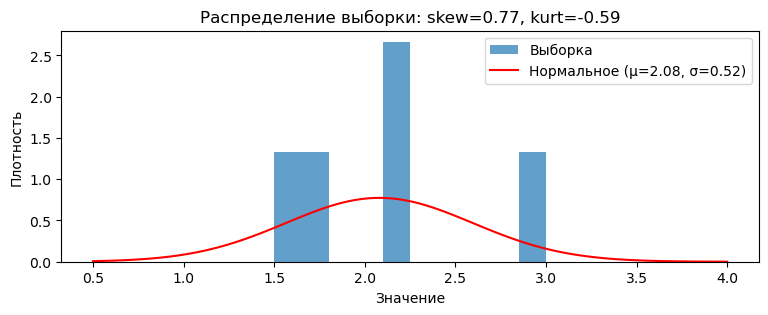

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Сравнение с нормальным распределением
x_range = np.linspace(min(x)-1, max(x)+1, 100)
pdf_norm = norm.pdf(x_range, a1, s)

plt.figure(figsize=(9, 3))
plt.hist(x, bins=10, density=True, alpha=0.7, label='Выборка')
plt.plot(x_range, pdf_norm, 'r-', label=f'Нормальное (μ={a1:.2f}, σ={s:.2f})')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.title(f'Распределение выборки: skew={skew:.2f}, kurt={kurt:.2f}')
plt.legend()
plt.show()

In [8]:
import pandas as pd
sample = pd.DataFrame([ 1.0 , 2.5 , 3.0 , 4.5 ])
sample.describe()

,0
count,4.000000
mean,2.750000
std,1.443376
min,1.000000
25%,2.125000
50%,2.750000
75%,3.375000
max,4.500000


## Построение графиков распределения

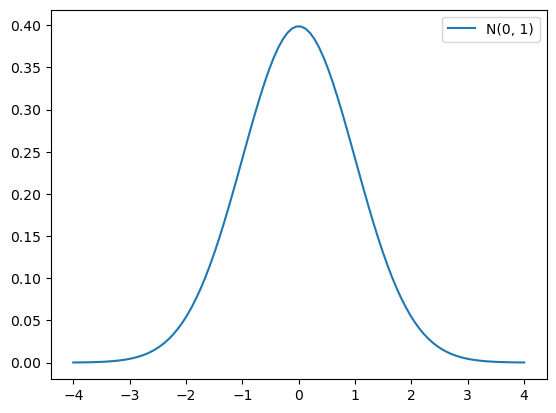

In [15]:
from scipy.stats import norm         # для работы с нормальным распределением
import numpy as np                      # для создания массива чисел
import matplotlib.pyplot as plt       # для построения графиков

x = np.linspace(-4, 4, 100)            # Генерирует 100 точек в диапазоне от −4 до 4.
pdf = norm.pdf(x, loc=0, scale=1) # вычисление плотности вероятности
plt.plot(x, pdf, label="N(0, 1)")      # рисует кривую
plt.legend()                                   # добавляет легенду
plt.show()                                     # отображает график

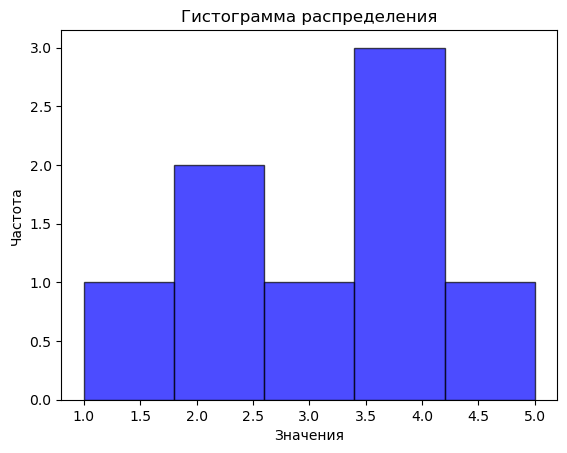

In [18]:
# Пример кода для построения гистограммы с использованием Matplotlib:

import matplotlib.pyplot as plt     # импортируем библиотеку
data = [1, 2, 2, 3, 4, 4, 4, 5]     # определяем массив данных
plt.hist(data, bins=5, alpha=0.7, color='blue', edgecolor='black') # рисуем гистограмму с 5 бинами, прозрачность столбцов 0.7, цвет заливки синий и границ - черный
plt.title("Гистограмма распределения") # название графика

#подписи осей
plt.xlabel("Значения")
plt.ylabel("Частота")
plt.show()

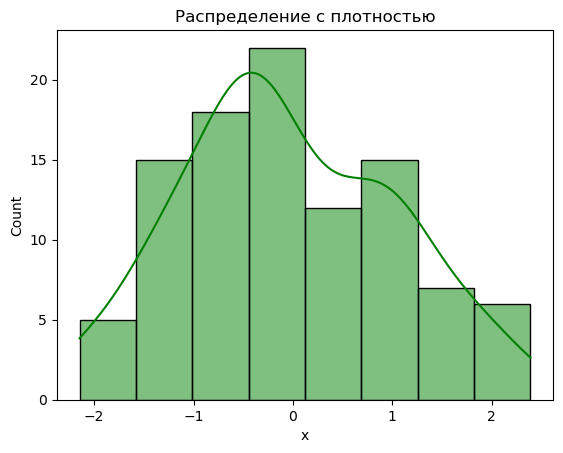

In [19]:
import seaborn as sns # импорт библиотек
import pandas as pd
#создаем датафрейм из 100 случайных чисел, взятых из стандартного нормального распределения
data = pd.DataFrame({'x': np.random.normal(size=100)})
#Построение гистограммы с KDE (Kernel Density Estimation) — гладкую кривую плотности.
sns.histplot(data['x'], kde=True, color='green')
plt.title("Распределение с плотностью")
plt.show()

Рассмотрим пример построения графиков PMF с использованием языка программирования Python


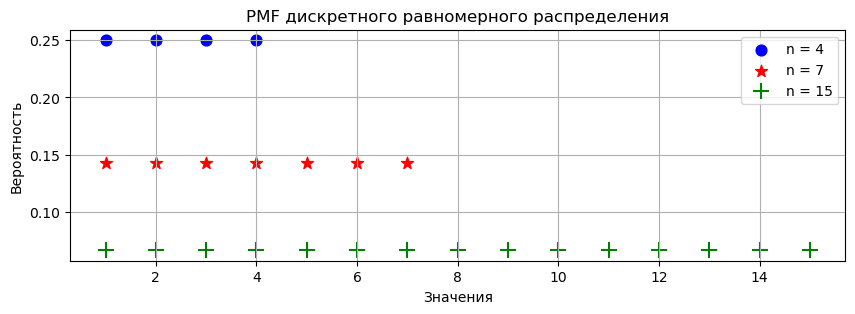

In [23]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import randint         	# Импортируем метод randint
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазоны значений
x1 = np.arange(1, 5)                    	# Значения для n = 4
x2 = np.arange(1, 8)                    	# Значения для n = 7
x3 = np.arange(1, 16)                   	# Значения для n = 15

# Строим графики PMF
plt.scatter(x1, randint.pmf(x1, 1, 5), s=60, c="blue", marker="o", label='n = 4')
plt.scatter(x2, randint.pmf(x2, 1, 8), s=80, c="red", marker="*", label='n = 7')
plt.scatter(x3, randint.pmf(x3, 1, 16), s=120, c="green", marker="+", label='n = 15')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF дискретного равномерного распределения")
plt.xlabel("Значения")
plt.ylabel("Вероятность")
plt.show()

Функция CDF для дискретного равномерного распределения реализуется на Python следующим образом



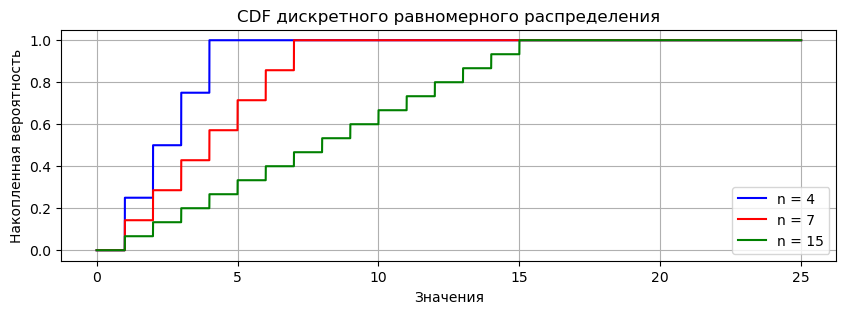

In [22]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import randint         	# Импортируем метод randint
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазоны значений
x = np.arange(0, 25, 0.001)             	# Создаем массив чисел от 0 до 25 с шагом 0.001

# Строим графики CDF
plt.plot(x, randint.cdf(x, 1, 5), c="blue", label='n = 4')   # CDF для n = 4
plt.plot(x, randint.cdf(x, 1, 8), c="red", label='n = 7')	# CDF для n = 7
plt.plot(x, randint.cdf(x, 1, 16), c="green", label='n = 15') # CDF для n = 15

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF дискретного равномерного распределения")
plt.xlabel("Значения")
plt.ylabel("Накопленная вероятность")
plt.show()


Посмотрим, как графически показать PMF и CDF распределения Бернулли в Python.

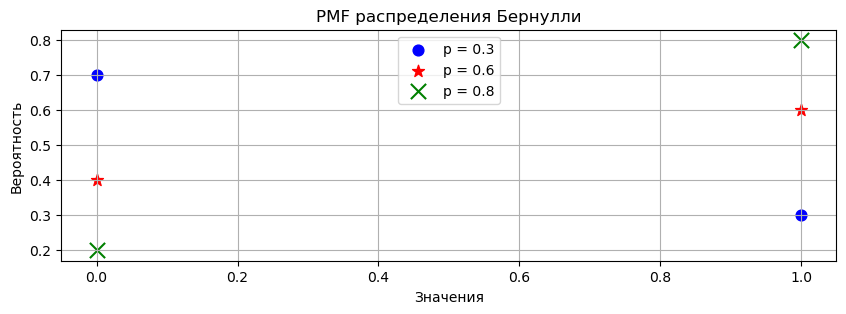

In [24]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import bernoulli       	# Импортируем метод bernoulli
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазон значений
x = np.arange(0, 2)                     	# Значения 0 и 1

# Строим графики PMF
plt.scatter(x, bernoulli.pmf(x, 0.3), s=60, c="blue", marker="o", label='p = 0.3')
plt.scatter(x, bernoulli.pmf(x, 0.6), s=80, c="red", marker="*", label='p = 0.6')
plt.scatter(x, bernoulli.pmf(x, 0.8), s=120, c="green", marker="x", label='p = 0.8')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper center')

# Отображаем график
plt.title("PMF распределения Бернулли")
plt.xlabel("Значения")
plt.ylabel("Вероятность")
plt.show()

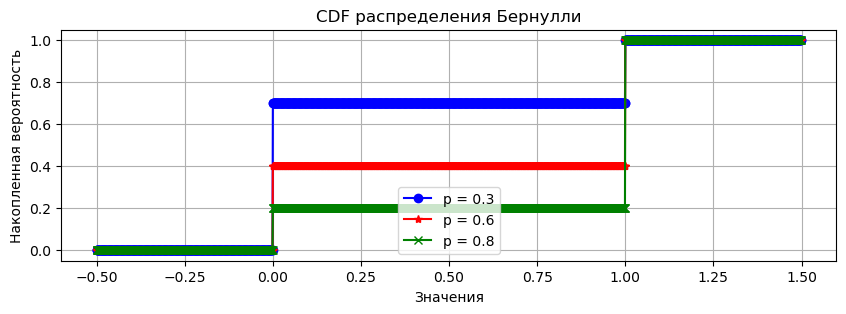

In [26]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import bernoulli       	# Импортируем метод bernoulli
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазон значений
x = np.arange(-0.5, 1.5, 0.001)

# Строим графики CDF
plt.plot(x, bernoulli.cdf(x, 0.3), c="blue", marker="o", label='p = 0.3')
plt.plot(x, bernoulli.cdf(x, 0.6), c="red", marker="*", label='p = 0.6')
plt.plot(x, bernoulli.cdf(x, 0.8), c="green", marker="x", label='p = 0.8')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower center')

# Отображаем график
plt.title("CDF распределения Бернулли")
plt.xlabel("Значения")
plt.ylabel("Накопленная вероятность")
plt.show()

Посмотрим, как графически показать PMF и CDF биномиального распределения в Python.

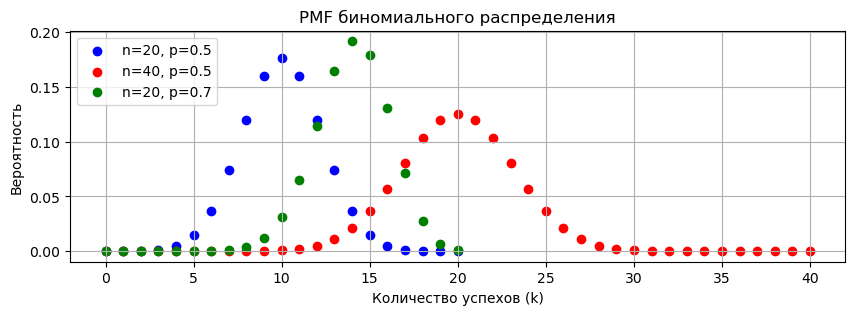

In [28]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 20, 0.5
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='b', label='n=20, p=0.5')

n, p = 40, 0.5
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='r', label='n=40, p=0.5')

n, p = 20, 0.7
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='g', label='n=20, p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper left')

# Отображаем график
plt.title("PMF биномиального распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Вероятность")
plt.show()

Функция CDF показывает накопленную вероятность для значений $k$:

$F(X \le k) = \sum_{i=0}^k P(X = i)$

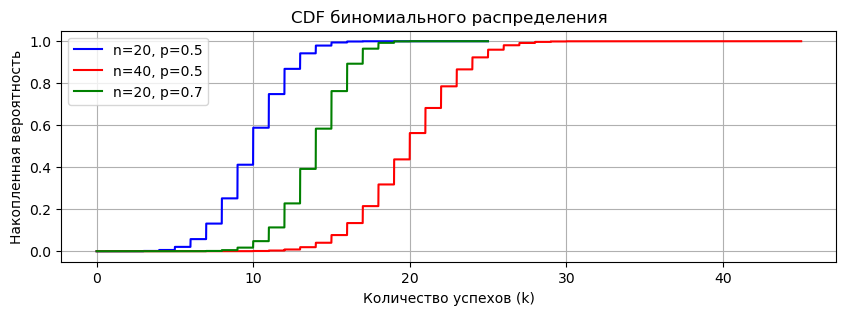

In [29]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 20, 0.5
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='b', label='n=20, p=0.5')

n, p = 40, 0.5
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='r', label='n=40, p=0.5')

n, p = 20, 0.7
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='g', label='n=20, p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper left')

# Отображаем график
plt.title("CDF биномиального распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

**Геометрическое распределение**

Посмотрим, как графически показать PMF и CDF геометрического распределения в Python. Функция PMF геометрического распределения показывает вероятность того, что первый успех произойдет на $k$-м испытании:

$P(X = k) = (1-p)^{k-1} p$

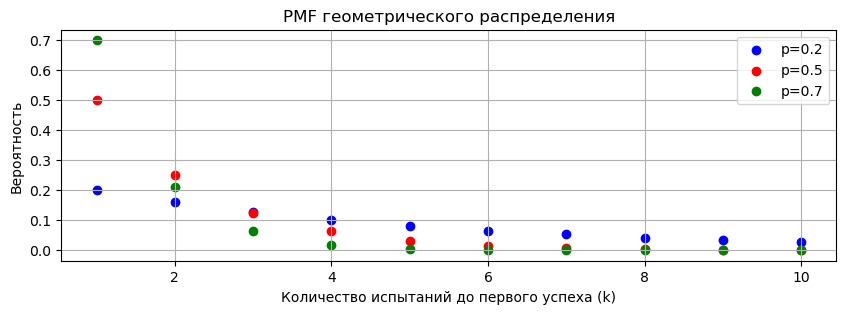

In [31]:
import numpy as np
from scipy.stats import geom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
p = 0.2
x = np.arange(1, 11)  # Значения от 1 до 10
plt.scatter(x, geom.pmf(x, p), c='b', label='p=0.2')

p = 0.5
plt.scatter(x, geom.pmf(x, p), c='r', label='p=0.5')

p = 0.7
plt.scatter(x, geom.pmf(x, p), c='g', label='p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF геометрического распределения")
plt.xlabel("Количество испытаний до первого успеха (k)")
plt.ylabel("Вероятность")
plt.show()

Функция CDF показывает накопленную вероятность для значений $k$:

$F(X\le k ) = 1 − (1-p)^{⌊k⌋}, k \geq 1.$

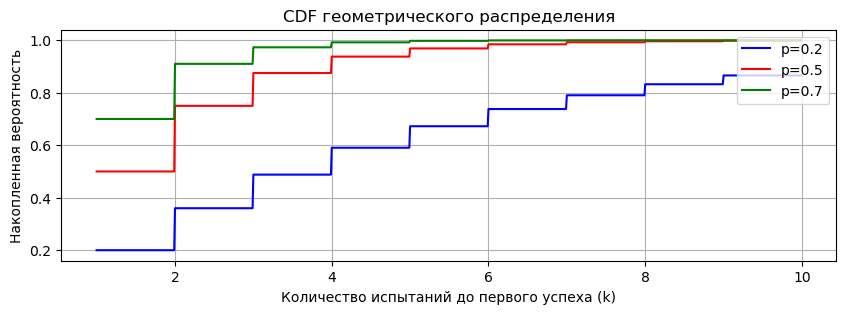

In [32]:
import numpy as np
from scipy.stats import geom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
p = 0.2
x = np.arange(1, 10, 0.01)
plt.plot(x, geom.cdf(x, p), c='b', label='p=0.2')

p = 0.5
plt.plot(x, geom.cdf(x, p), c='r', label='p=0.5')

p = 0.7
plt.plot(x, geom.cdf(x, p), c='g', label='p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("CDF геометрического распределения")
plt.xlabel("Количество испытаний до первого успеха (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

Геометрическое распределение также является частным случаем отрицательного биномиального распределения.

**Отрицательное биномиальное распределение**

Отрицательное биномиальное распределение — это дискретное распределение вероятностей, которое моделирует количество неудач в последовательности независимых и идентично распределённых испытаний Бернулли до того, как произойдёт заданное (неслучайное) количество успехов (обозначается $r$).

Распределение Паскаля и распределение Поля́ являются частными случаями отрицательного биномиального распределения. Среди инженеров, климатологов и других специалистов принято использовать «Паскаля» для случая целочисленного параметра времени остановки $r$ и использовать «Поля́» для вещественного случая. Чаще используется «Паскаль».

Функция PMF отрицательного биномиального распределения показывает вероятность получения $r$ неудач до $k$-го успеха:

$P(X=k)= \begin{pmatrix} k+r-1 \\ k \end{pmatrix} \cdot p^r \cdot q^k$, где $\begin{pmatrix} k+r-1 \\ k \end{pmatrix}$  — биномиальный коэффициент.



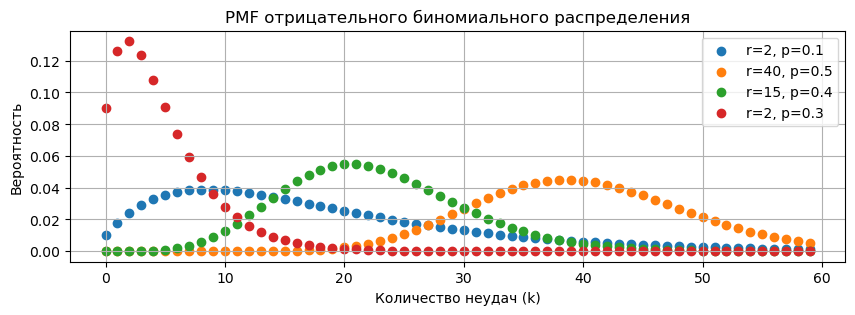

In [33]:
import numpy as np
from scipy.stats import nbinom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 2, 0.1
x = np.arange(0, n * 30, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=2, p=0.1')

n, p = 40, 0.5
x = np.arange(0, n * 1.5, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=40, p=0.5')

n, p = 15, 0.4
x = np.arange(0, n * 4, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=15, p=0.4')

n, p = 2, 0.3
x = np.arange(0, n * 30, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=2, p=0.3')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF отрицательного биномиального распределения")
plt.xlabel("Количество неудач (k)")
plt.ylabel("Вероятность")
plt.show()


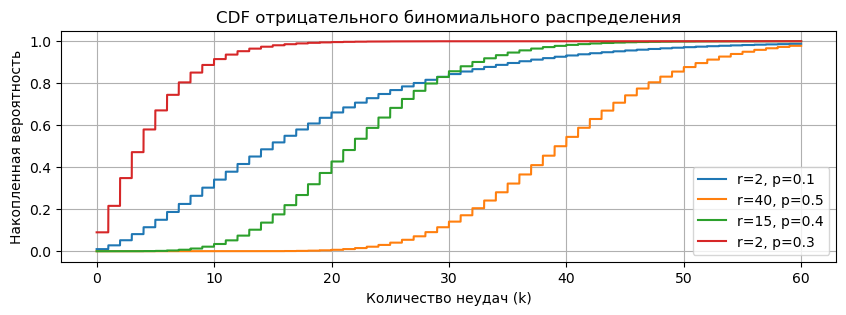

In [34]:
import numpy as np
from scipy.stats import nbinom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 2, 0.1
x = np.arange(0, n * 30, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=2, p=0.1')

n, p = 40, 0.5
x = np.arange(0, n * 1.5, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=40, p=0.5')

n, p = 15, 0.4
x = np.arange(0, n * 4, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=15, p=0.4')

n, p = 2, 0.3
x = np.arange(0, n * 30, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=2, p=0.3')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF отрицательного биномиального распределения")
plt.xlabel("Количество неудач (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

**Гипергеометрическое распределение**

Пусть общая совокупность содержит $N$ объектов, из них $D$ помечены как «$1$», а $N-D$ как «$0$». Будем считать выбор объекта с меткой «$1$», как успех, а с меткой «$0$» как неудачу. Проведём $n$ испытаний, причём выбранные объекты больше не будут участвовать в дальнейших испытаниях (без возвращения). Вероятность наступления $k$ успехов будет подчиняться гипергеометрическому распределению.

Таким образом, мы перешли к ситуации без возвращения и описываем вероятность количества успешных выборок из совокупности с заранее известным количеством успехов и неудач (заранее известное количество белых и чёрных мячей в корзине, козырных карт в колоде, бракованных деталей в партии и т. д.). Причём вероятность исхода меняется от испытания к испытанию. При больших $N$ и малых $n/N$ гипергеометрическое распределение можно аппроксимировать биномиальным распределением.

Посмотрим, как графически показать PMF и CDF гипергеометрического распределения в Python. Функция PMF гипергеометрического распределения показывает вероятность получения ровно  успехов в выборке:

$P(X = k) = \frac{\begin{pmatrix} D \\ k \end{pmatrix} \cdot \begin{pmatrix} N-D \\ n-k \end{pmatrix} }{\begin{pmatrix} N \\ n \end{pmatrix} }$ или $\frac{C^k_DC^{n-k}_{N-D}}{C^n_N}$

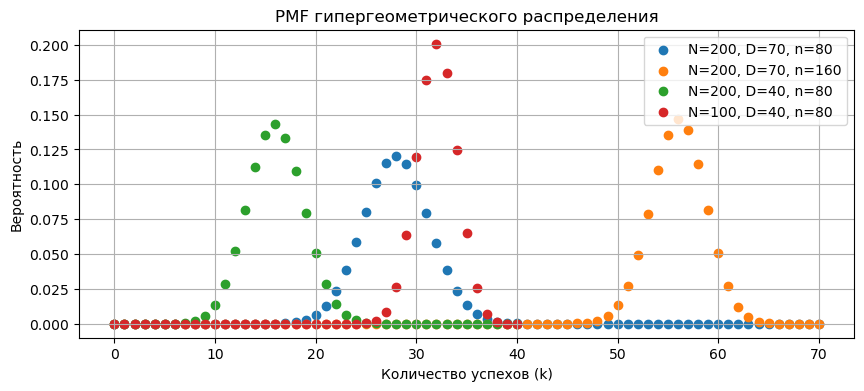

In [3]:
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
import numpy as np

# Создаем поле для графика
plt.figure(figsize=(10, 4))

# Определяем параметры
[M, n, N] = [200, 70, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=200, D=70, n=80')

[M, n, N] = [200, 70, 160]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=200, D=70, n=160')

[M, n, N] = [200, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=200, D=40, n=80')

[M, n, N] = [100, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=100, D=40, n=80')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF гипергеометрического распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Вероятность")
plt.show()

Функция CDF показывает накопленную вероятность для значений $k$:

$F(X \le k) = \sum_{i = max(0, n+D-N)}^k P(X=i)$

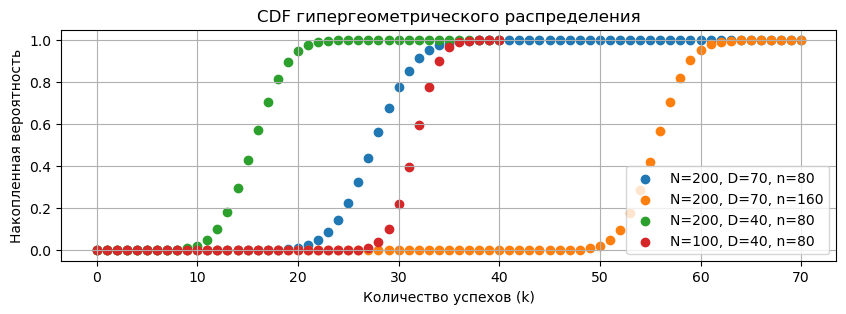

In [4]:
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
import numpy as np

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
[M, n, N] = [200, 70, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=200, D=70, n=80')

[M, n, N] = [200, 70, 160]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=200, D=70, n=160')

[M, n, N] = [200, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=200, D=40, n=80')

[M, n, N] = [100, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=100, D=40, n=80')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF гипергеометрического распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

**Распределение Пуассона**

Распределение Пуассона описывает вероятность наступления $k$ независимых событий при средней интенсивности событий $\lambda$. В данном случае $\lambda$ — безразмерная величина, равная произведению времени наблюдения и частоты возникновения событий.

Посмотрим, как графически показать PMF и CDF распределения Пуассона в Python. Функция PMF распределения Пуассона показывает вероятность наступления ровно $k$ событий:

$P(X = k) = \frac{\lambda^k}{k!} e^{- \lambda}$




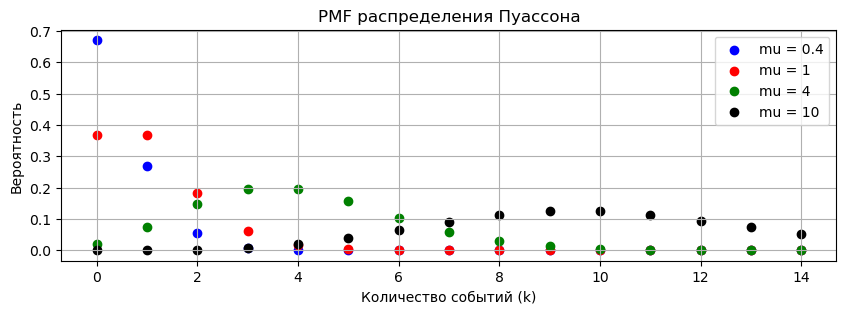

In [6]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
x = np.arange(0, 15, 1)
plt.scatter(x, poisson.pmf(x, 0.4), c='b', label='mu = 0.4')
plt.scatter(x, poisson.pmf(x, 1), c='r', label='mu = 1')
plt.scatter(x, poisson.pmf(x, 4), c='g', label='mu = 4')
plt.scatter(x, poisson.pmf(x, 10), c='black', label='mu = 10')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF распределения Пуассона")
plt.xlabel("Количество событий (k)")
plt.ylabel("Вероятность")
plt.show()

Функция CDF показывает накопленную вероятность для значений $k$:
$F(X\le k) = \sum_{i=0}^k P(X = i)$

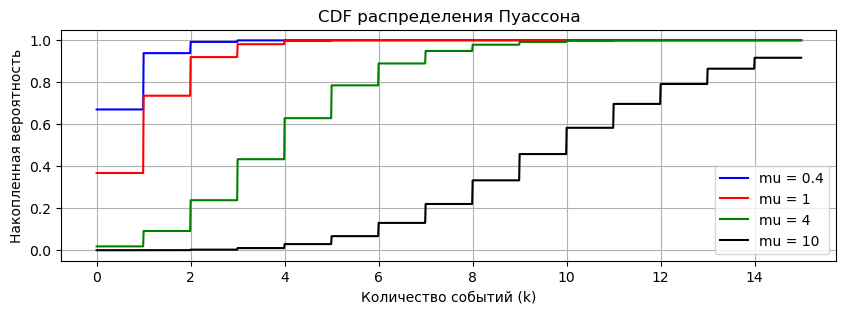

In [8]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
x = np.arange(0, 15, 0.01)
plt.plot(x, poisson.cdf(x, 0.4), c='b', label='mu = 0.4')
plt.plot(x, poisson.cdf(x, 1), c='r', label='mu = 1')
plt.plot(x, poisson.cdf(x, 4), c='g', label='mu = 4')
plt.plot(x, poisson.cdf(x, 10), c='black', label='mu = 10')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF распределения Пуассона")
plt.xlabel("Количество событий (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

## Абсолютно непрерывные распределения вероятностей

$P(X = c) = \lim_{\epsilon \to 0}P (c \le P \le c + \epsilon) = \int_{c}^{c} f(x) dx = 0.$

### Абсолютно непрерывное равномерное распределение

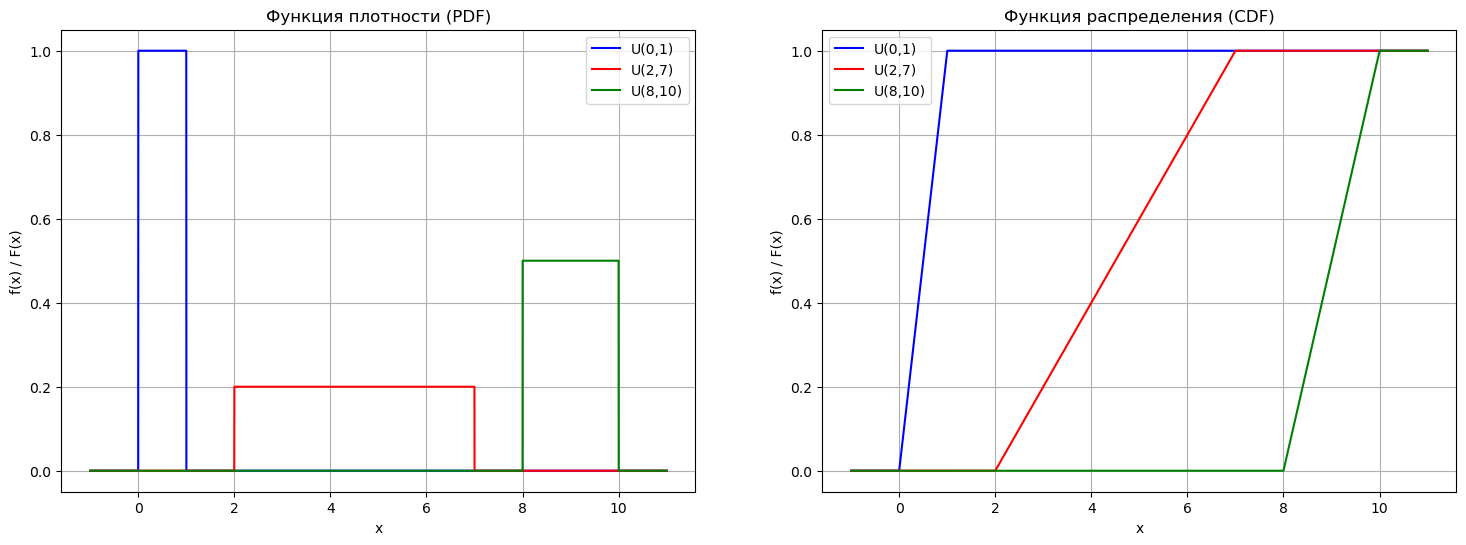

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Настройки графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PDF
x = np.linspace(-1, 11, 5000)
ax1.plot(x, uniform.pdf(x), 'b', label='U(0,1)')
ax1.plot(x, uniform.pdf(x, loc=2, scale=5), 'r', label='U(2,7)')
ax1.plot(x, uniform.pdf(x, loc=8, scale=2), 'g', label='U(8,10)')
ax1.set_title('Функция плотности (PDF)')
ax1.grid(True)

# CDF
ax2.plot(x, uniform.cdf(x), 'b', label='U(0,1)')
ax2.plot(x, uniform.cdf(x, loc=2, scale=5), 'r', label='U(2,7)')
ax2.plot(x, uniform.cdf(x, loc=8, scale=2), 'g', label='U(8,10)')
ax2.set_title('Функция распределения (CDF)')
ax2.grid(True)

for ax in (ax1, ax2):
    ax.legend()
    ax.set_xlabel('x')
    ax.set_ylabel('f(x) / F(x)')
plt.show()

## Распределение Гаусса (нормальное распределение)

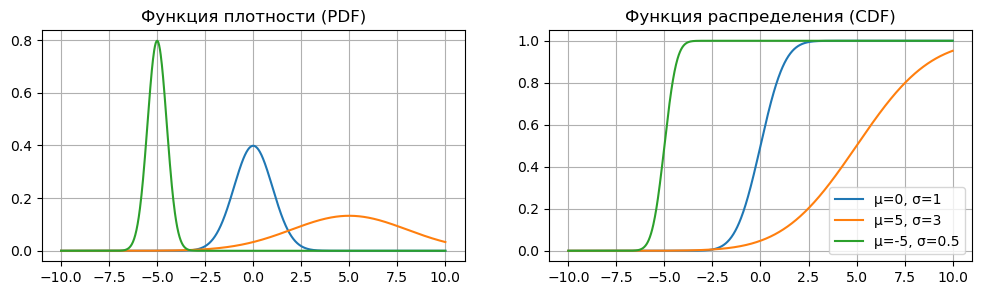

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Настройки графиков
plt.figure(figsize=(12, 3))

# PDF
x = np.linspace(-10, 10, 1000)
plt.subplot(121)
for params in [(0,1), (5,3), (-5,0.5)]:
    plt.plot(x, norm.pdf(x, *params), 
             label=f'μ={params[0]}, σ={params[1]}')
plt.title('Функция плотности (PDF)')
plt.grid(True)

# CDF
plt.subplot(122)
for params in [(0,1), (5,3), (-5,0.5)]:
    plt.plot(x, norm.cdf(x, *params),
             label=f'μ={params[0]}, σ={params[1]}')
plt.title('Функция распределения (CDF)')
plt.grid(True)

plt.legend()
plt.show()


## Экспоненциальное распределение


Экспоненциальное (показательное) распределение описывает интервалы времени между независимыми событиями, происходящими со средней интенсивностью $\lambda$. Количество наступлений таких событий за некоторый отрезок времени описывается дискретным распределением Пуассона. Экспоненциальное распределение, наряду с распределением Пуассона, составляет математическую основу теории надёжности.

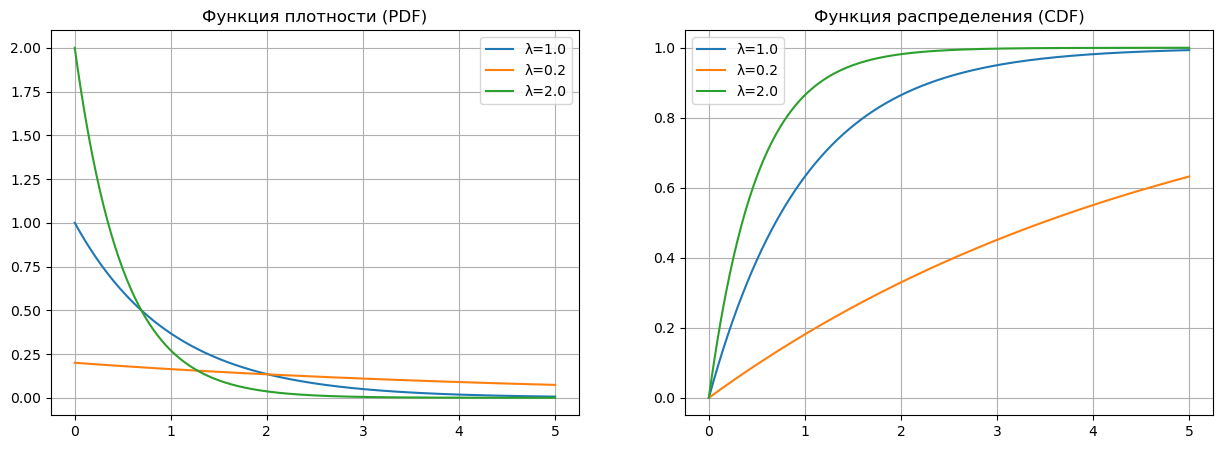

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# PDF
x = np.linspace(0, 5, 500)
for scale in [1, 1/0.2, 1/2]:
    ax1.plot(x, expon.pdf(x, scale=scale), 
             label=f'λ={1/scale:.1f}')
ax1.set_title('Функция плотности (PDF)')

# CDF
for scale in [1, 1/0.2, 1/2]:
    ax2.plot(x, expon.cdf(x, scale=scale), 
             label=f'λ={1/scale:.1f}')
ax2.set_title('Функция распределения (CDF)')

for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
plt.show()

## Распределение Лапласа


Если функцию плотности вероятностей экспоненциального распределения отразить зеркально в область отрицательных значений, то есть заменить $X$ на $|x|$, то получится распределение Лапласа, также называемое двойным экспоненциальным или двойным показательным. Для большего обобщения вводится параметр сдвига, смещающий центр «соединения» левой и правой частей распределения.

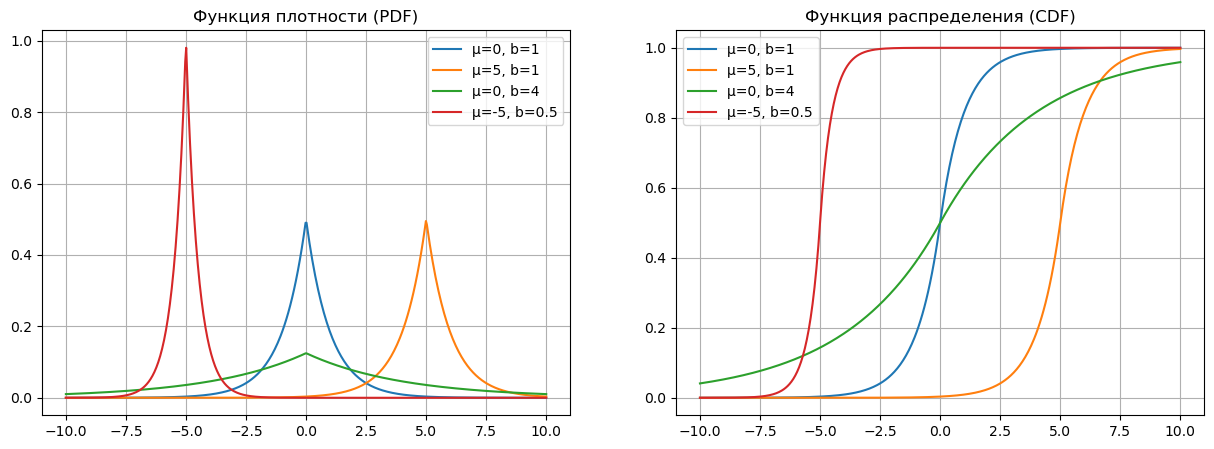

In [16]:
from scipy.stats import laplace
import matplotlib.pyplot as plt
import numpy as np
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# PDF
x = np.linspace(-10, 10, 500)
for (loc, scale) in [(0,1), (5,1), (0,4), (-5,0.5)]:
    ax1.plot(x, laplace.pdf(x, loc, scale),
             label=f'μ={loc}, b={scale}')
ax1.set_title('Функция плотности (PDF)')

# CDF
for (loc, scale) in [(0,1), (5,1), (0,4), (-5,0.5)]:
    ax2.plot(x, laplace.cdf(x, loc, scale),
             label=f'μ={loc}, b={scale}')
ax2.set_title('Функция распределения (CDF)')

for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
plt.show()

## Распределение Парето


Распределение Парето представляет собой степенное распределение вероятностей, которое используется при описании социальных, управленческих, научных, геофизических, актуарных и многих других типов наблюдаемых явлений.

Принцип, первоначально применявшийся для описания распределения богатства в обществе, соответствует тенденции, согласно которой большая часть богатства принадлежит небольшой части населения. Этот принцип привёл к возникновению «принципа Парето» или «правило $80-20$», утверждающего, что $80%$ результатов обусловлены $20%$ причин.

Распределения Парето со значением формы ($\alpha$) $\log_4 5\approx 1.16$ точно отражают это. Эмпирические наблюдения показали, что распределение $80-20$ подходит для широкого круга случаев, включая природные явления и деятельность человека.

$f(x) = \begin{cases} \frac{\alpha x^\alpha_m}{x^{\alpha + 1}}, & x \geq x_m \\0, & x < x_m \end{cases}$

$F(x) = 1 - \left( \frac{x_m}{x} \right)^\alpha, x \geq x_m$

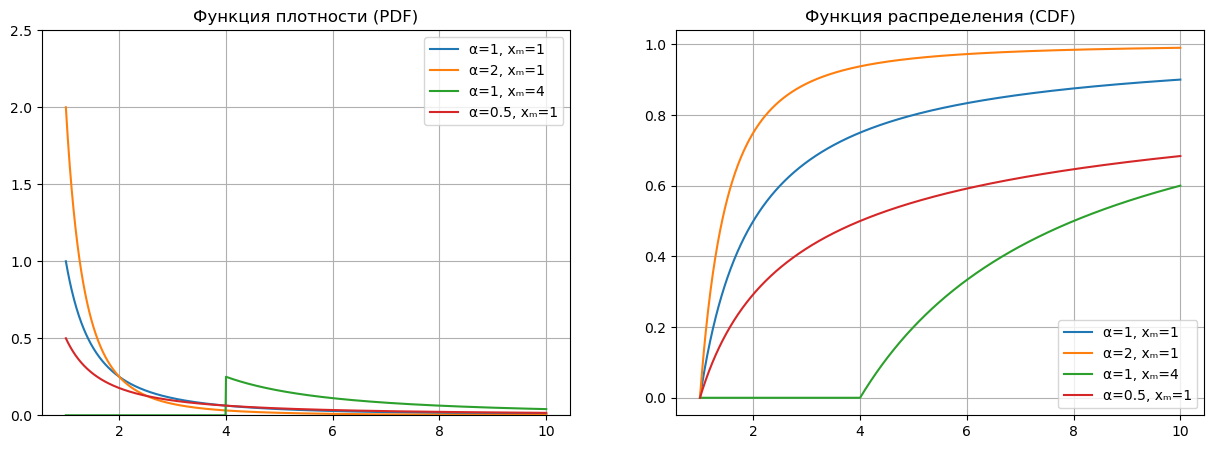

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pareto

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# PDF
x = np.linspace(1, 10, 1000)
for (a, xm) in [(1,1), (2,1), (1,4), (0.5,1)]:
    ax1.plot(x, pareto.pdf(x, a, scale=xm), 
             label=f'α={a}, xₘ={xm}')
ax1.set_title('Функция плотности (PDF)')
ax1.set_ylim(0, 2.5)

# CDF
for (a, xm) in [(1,1), (2,1), (1,4), (0.5,1)]:
    ax2.plot(x, pareto.cdf(x, a, scale=xm),
             label=f'α={a}, xₘ={xm}')
ax2.set_title('Функция распределения (CDF)')

for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
plt.show()

## Распределение Рэлея


Распределение Рэлея часто наблюдается, когда общая величина вектора на плоскости связана с его направленными компонентами.



Один из примеров, когда распределение Рэлея возникает естественным образом, — когда скорость ветра анализируется в двух измерениях. Предполагая, что каждый компонент не коррелирован, нормально распределён с равной дисперсией и нулевым средним значением, что встречается, хотя и не часто, общая скорость ветра (векторная величина) будет характеризоваться распределением Рэлея.

Второй пример распределения возникает в случае случайных комплексных чисел, действительная и мнимая составляющие которых распределены независимо и идентично по гауссову с равной дисперсией и нулевым средним. В этом случае абсолютное значение комплексного числа распределено по Рэлею.

$f(x)=\begin{cases}\frac{x}{\sigma^2}e^{-\frac{x^2}{2\sigma^2}},&x\geq0\\0,&x<0\end{cases}$

$F(x) = 1 - e^{- \frac{x^2}{ 2\sigma^2}}, x \geq 0$

Особенности:

* нулевая плотность в точке 0;
* мода = $\sigma$;
* быстрое убывание "хвостов".

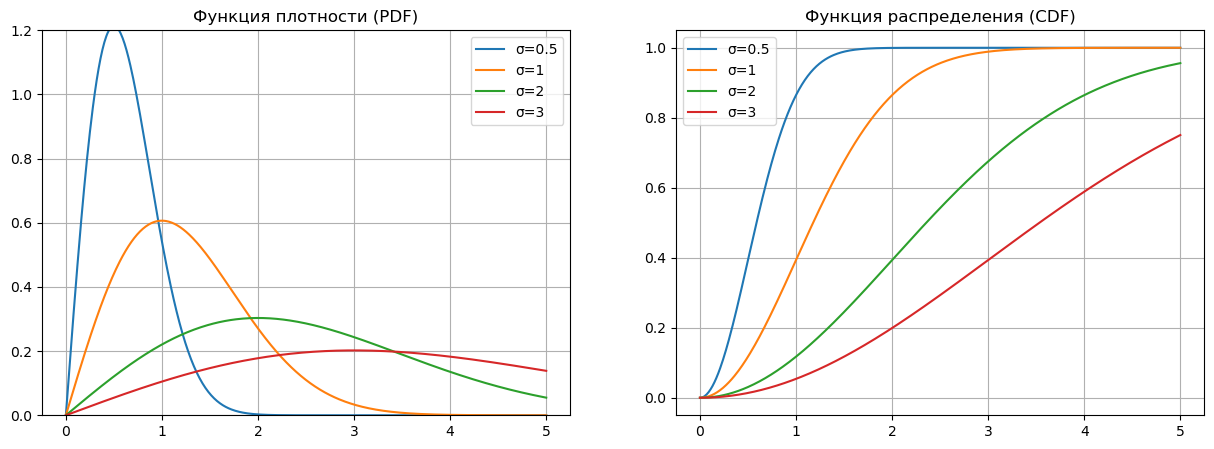

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# PDF
x = np.linspace(0, 5, 500)
for scale in [0.5, 1, 2, 3]:
    ax1.plot(x, rayleigh.pdf(x, scale=scale),
             label=f'σ={scale}')
ax1.set_title('Функция плотности (PDF)')
ax1.set_ylim(0, 1.2)

# CDF
for scale in [0.5, 1, 2, 3]:
    ax2.plot(x, rayleigh.cdf(x, scale=scale),
             label=f'σ={scale}')
ax2.set_title('Функция распределения (CDF)')

for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
plt.show()

## ДЗ 1
(8/12)

1.

In [21]:
floors = list(range(10, 20)) + list(range(35, 45))
np.var(floors)  # ddof=0 по умолчанию - это то, что нужно

164.5

In [24]:
(1 - np.exp(-0.8))**2

0.30323858976021223

In [25]:
0.551**2

0.30360100000000007

In [26]:
551**2

303601

**Задание 6.4**

Вам предлагается файл data.csv, содержащий шесть колонок и $10 000$ строк. В каждой колонке данные сгенерированы по некоторому закону распределения. Выберите верный закон распределения для данных из первой колонки column_1.

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [71]:
data = pd.read_csv('data.csv')

In [72]:
df = data.copy()

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   column_1  10000 non-null  float64
 1   column_2  10000 non-null  int64  
 2   column_3  10000 non-null  int64  
 3   column_4  10000 non-null  float64
 4   column_5  10000 non-null  float64
 5   column_6  10000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 468.9 KB


In [30]:
data.describe()

,column_1,column_2,column_3,column_4,column_5,column_6
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,29.901895,219.976900,29.956100,9.824039,20.034962,43.970700
std,5.013924,9.774319,4.479886,14.098701,2.888833,3.443287
min,10.482299,181.000000,16.000000,-87.851913,15.000092,41.000000
25%,26.518357,213.000000,27.000000,2.741335,17.572796,41.000000
50%,29.889800,220.000000,30.000000,9.822522,20.042798,43.000000
75%,33.223838,226.000000,33.000000,16.918443,22.554111,45.000000
max,49.207994,258.000000,50.000000,107.992242,24.999425,80.000000


In [ ]:

plt.hist(data[column], bins = 50, range=(low, high), alpha=0.6, label='Данные')


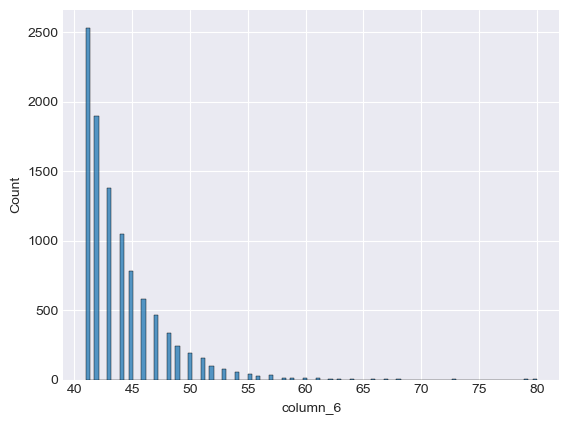

In [113]:
col = 'column_6'
sns.histplot(df[col])
plt.show()

In [53]:
# Параметры
x_min, x_max = df[col].min(), df[col].max()
x_range = np.linspace(x_min, x_max, 10000)
mean, std = df[col].mean(), df[col].std()

# Нормальное
ax.plot(x_range, stats.norm.pdf(x_range, mean, std), 
        'b-', lw=2, label='Нормальное', alpha=0.7)

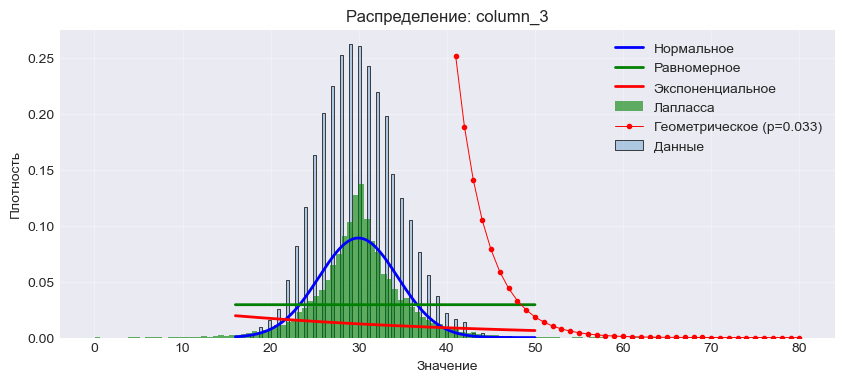

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Загрузка
df = pd.read_csv('data.csv')
column_no = 2
bins=100
data = df.iloc[:, column_no].dropna()


# Основной график
plt.figure(figsize=(10, 4))
sns.histplot(data, bins=bins, stat='density', alpha=0.3, label='Данные')

# Диапазон для линий
x = np.linspace(data.min(), data.max(), 10000)

# Распределения
plt.plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'b-', label='Нормальное', lw=2)
plt.plot(x, stats.uniform.pdf(x, data.min(), data.max()-data.min()), 'g-', label='Равномерное', lw=2)

if data.min() >= 0:
    plt.plot(x, stats.expon.pdf(x, scale=data.mean()), 'r-', label='Экспоненциальное', lw=2)

# Лапласса
# Задайте параметры распределения
loc = data.median()   # Параметр сдвига (среднее) или медиана
scale = np.mean(np.abs(data - loc)) # Параметр масштаба
size = 10000 # Количество образцов

# Сгенерируйте данные
laplace_data = np.random.laplace(loc, scale, size)

# Постройте гистограмму для визуализации
plt.hist(laplace_data, bins=bins, density=True, alpha=0.6, color='g', label='Лапласса')

# Геометрическое
# (Не) Смещаем данные, так как геометрическое распределение начинается с 1
data_shifted = data # - np.min(data) + 1  # Сдвигаем к 1
p_estimate = 1 / np.mean(data_shifted)

# Теоретическое геометрическое распределение
k_values = np.arange(np.min(data_shifted), np.max(data_shifted))
pmf_geom = stats.geom.pmf(k_values, p_estimate)

# 5. Генерация данных по оцененному распределению
n_samples = 10000
geom_data = stats.geom.rvs(p_estimate, size=n_samples) + np.min(data)

plt.plot(k_values_theor, pmf_theor, 'ro-', linewidth=0.7, markersize=3,
        label=f'Геометрическое (p={p_estimate:.3f})')
# Постройте гистограмму для визуализации
# plt.hist(geom_data, bins=bins, density=True, alpha=0.6, color='y', label='Геометрическое')


plt.title(f'Распределение: {df.columns[column_no]}')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [147]:
data.describe()

count    10000.000000
mean        29.956100
std          4.479886
min         16.000000
25%         27.000000
50%         30.000000
75%         33.000000
max         50.000000
Name: column_3, dtype: float64

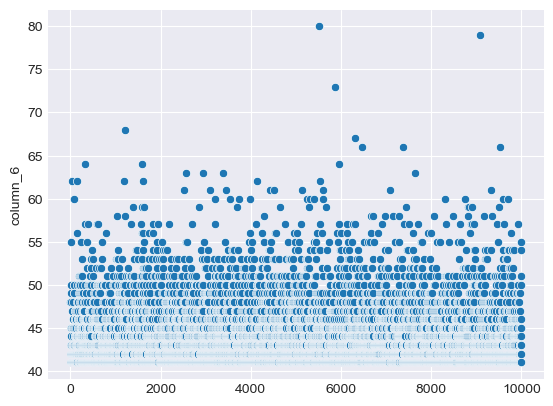

In [117]:
sns.scatterplot(data)
plt.show()

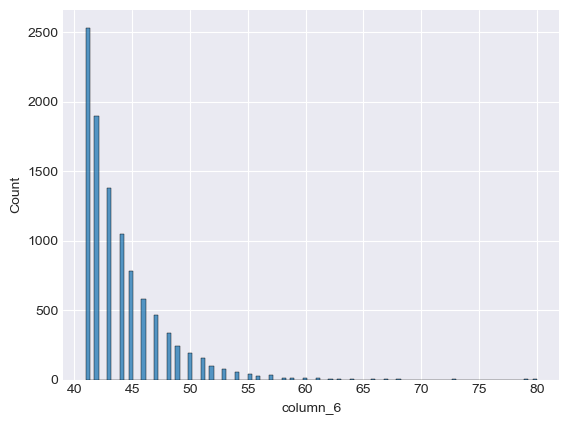

In [119]:
sns.histplot(data)
plt.show()

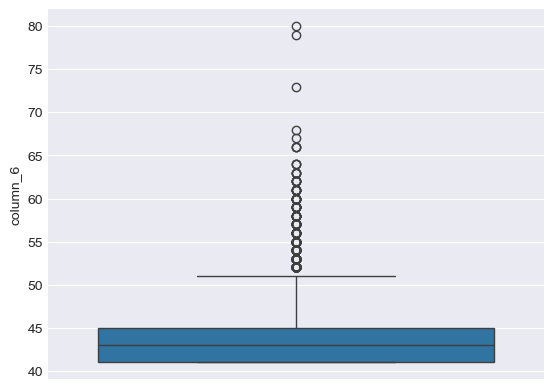

In [120]:
sns.boxplot(data)
plt.show()

In [121]:
data

0       48
1       42
2       44
3       41
4       50
        ..
9995    43
9996    51
9997    43
9998    42
9999    43
Name: column_6, Length: 10000, dtype: int64

In [122]:
data.value_counts()

column_6
41    2533
42    1899
43    1377
44    1046
45     784
46     579
47     465
48     333
49     244
50     190
51     155
52      97
53      79
54      53
55      41
57      32
56      24
58      13
60      13
59      13
61       9
62       6
63       4
64       3
66       3
67       1
68       1
73       1
80       1
79       1
Name: count, dtype: int64

Анализ колонки column_6:
Количество значений: 10000
Минимум: 41
Максимум: 80
Уникальные значения: [41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64
 66 67 68 73 79 80]

Оценка параметра p: 0.2518


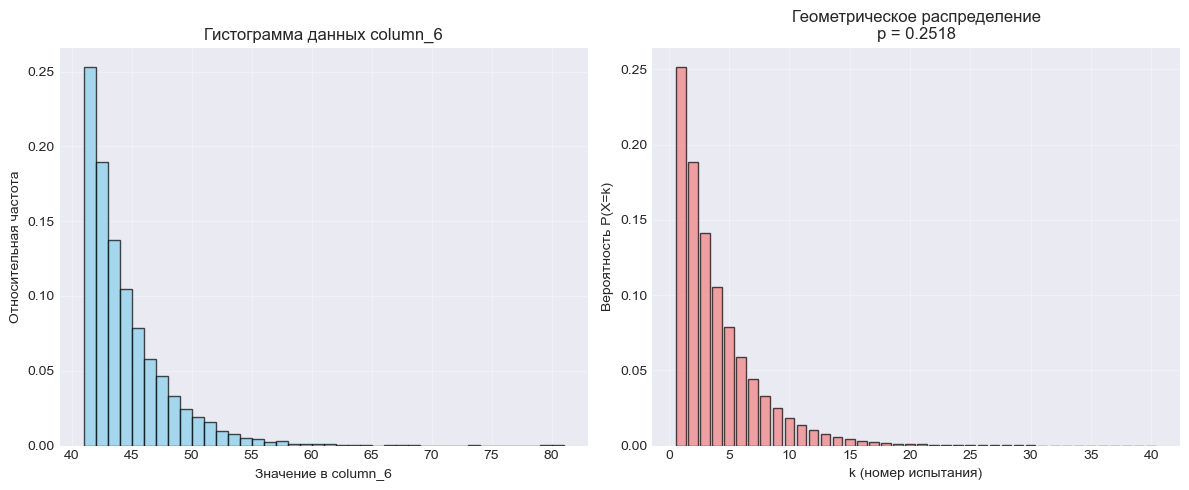

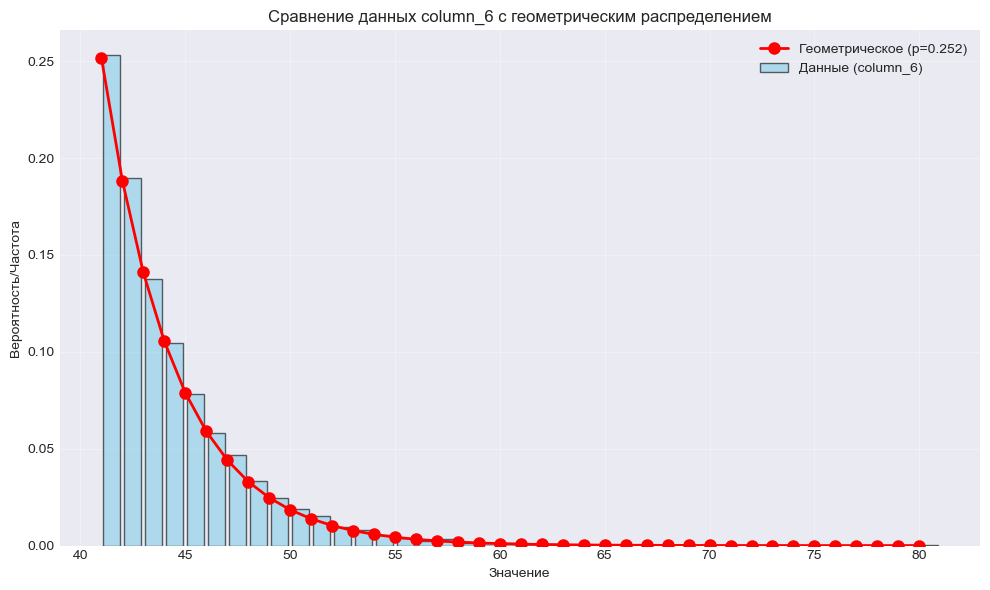


Характеристики геометрического распределения с p = 0.2518:
Математическое ожидание: 1/p = 3.97
Дисперсия: (1-p)/p² = 11.80
Наиболее вероятное значение: 1 (мода)
Вероятность успеха с первой попытки: 0.2518

Сгенерировано 1000 значений:
Среднее сгенерированных: 44.09
Среднее исходных данных: 43.97


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Загрузка данных
df = pd.read_csv('data.csv')
data = df['column_6'].values

print(f"Анализ колонки column_6:")
print(f"Количество значений: {len(data)}")
print(f"Минимум: {np.min(data)}")
print(f"Максимум: {np.max(data)}")
print(f"Уникальные значения: {np.unique(data)}")

# 1. Оценим параметр p для геометрического распределения
# Геометрическое распределение: P(X=k) = p*(1-p)^(k-1), где k=1,2,3,...
# Оценка максимального правдоподобия: p̂ = 1/mean

# Смещаем данные, так как геометрическое распределение начинается с 1
data_shifted = data - np.min(data) + 1  # Сдвигаем к 1
p_estimate = 1 / np.mean(data_shifted)

print(f"\nОценка параметра p: {p_estimate:.4f}")

# 2. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма данных
axes[0].hist(data, bins=range(np.min(data), np.max(data)+2), 
             density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Значение в column_6')
axes[0].set_ylabel('Относительная частота')
axes[0].set_title('Гистограмма данных column_6')
axes[0].grid(True, alpha=0.3)

# Теоретическое геометрическое распределение
k_values = np.arange(np.min(data_shifted), np.max(data_shifted)+1)
pmf_geom = stats.geom.pmf(k_values, p_estimate)

axes[1].bar(k_values, pmf_geom, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('k (номер испытания)')
axes[1].set_ylabel('Вероятность P(X=k)')
axes[1].set_title(f'Геометрическое распределение\np = {p_estimate:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Сравнение эмпирического и теоретического распределений
fig, ax = plt.subplots(figsize=(10, 6))

# Эмпирическое распределение (нормализованная гистограмма)
hist_values, bin_edges = np.histogram(data, bins=range(np.min(data), np.max(data)+2), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Теоретическое распределение (с учетом сдвига)
k_values_theor = np.arange(np.min(data), np.max(data)+1)
k_values_shifted = k_values_theor - np.min(data) + 1
pmf_theor = stats.geom.pmf(k_values_shifted, p_estimate)

ax.bar(bin_centers, hist_values, alpha=0.6, color='skyblue', 
       width=0.8, label='Данные (column_6)', edgecolor='black')
ax.plot(k_values_theor, pmf_theor, 'ro-', linewidth=2, markersize=8, 
        label=f'Геометрическое (p={p_estimate:.3f})')

ax.set_xlabel('Значение')
ax.set_ylabel('Вероятность/Частота')
ax.set_title('Сравнение данных column_6 с геометрическим распределением')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Основные характеристики
print(f"\nХарактеристики геометрического распределения с p = {p_estimate:.4f}:")
print(f"Математическое ожидание: 1/p = {1/p_estimate:.2f}")
print(f"Дисперсия: (1-p)/p² = {(1-p_estimate)/(p_estimate**2):.2f}")
print(f"Наиболее вероятное значение: 1 (мода)")
print(f"Вероятность успеха с первой попытки: {p_estimate:.4f}")

# 5. Генерация данных по оцененному распределению
n_samples = 1000
generated_data = stats.geom.rvs(p_estimate, size=n_samples) + np.min(data) - 1

print(f"\nСгенерировано {n_samples} значений:")
print(f"Среднее сгенерированных: {np.mean(generated_data):.2f}")
print(f"Среднее исходных данных: {np.mean(data):.2f}")

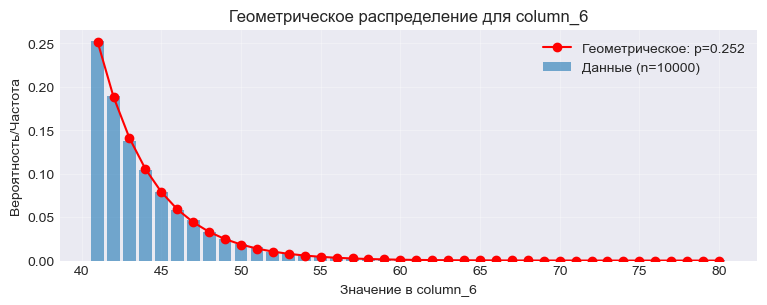

Оцененный параметр p = 0.2518
Среднее: 3.97


In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Загрузка и подготовка данных
df = pd.read_csv('data.csv')
data = df['column_6'].values

# Оценка параметра p
data_shifted = data - np.min(data) + 1
p_est = 1 / np.mean(data_shifted)

# Визуализация
plt.figure(figsize=(9, 3))

# Эмпирическое распределение
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

# Теоретическое распределение
k_theor = np.arange(np.min(data), np.max(data)+1)
k_shifted = k_theor - np.min(data) + 1
pmf_theor = stats.geom.pmf(k_shifted, p_est)

plt.bar(values, probs, alpha=0.6, label=f'Данные (n={len(data)})', width=0.8)
plt.plot(k_theor, pmf_theor, 'ro-', label=f'Геометрическое: p={p_est:.3f}')

plt.xlabel('Значение в column_6')
plt.ylabel('Вероятность/Частота')
plt.title('Геометрическое распределение для column_6')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Оцененный параметр p = {p_est:.4f}")
print(f"Среднее: {1/p_est:.2f}")

In [130]:
probs

array([2.533e-01, 1.899e-01, 1.377e-01, 1.046e-01, 7.840e-02, 5.790e-02,
       4.650e-02, 3.330e-02, 2.440e-02, 1.900e-02, 1.550e-02, 9.700e-03,
       7.900e-03, 5.300e-03, 4.100e-03, 2.400e-03, 3.200e-03, 1.300e-03,
       1.300e-03, 1.300e-03, 9.000e-04, 6.000e-04, 4.000e-04, 3.000e-04,
       3.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04])

In [152]:
df['column_6'].describe()

count    10000.000000
mean        43.970700
std          3.443287
min         41.000000
25%         41.000000
50%         43.000000
75%         45.000000
max         80.000000
Name: column_6, dtype: float64

In [143]:
np.var(df['column_1'])

25.13691754010069

Доступные колонки: ['column_1', 'column_2', 'column_3', 'column_4', 'column_5', 'column_6']

Анализ данных:
Количество значений: 10000
Минимум: 16
Максимум: 50
Среднее: 29.96
Дисперсия: 20.07

Оценка параметра λ: 29.9561

Эмуляция распределения Пуассона:
Сгенерировано 1000 значений
Среднее сгенерированных: 30.03
Дисперсия сгенерированных: 27.15


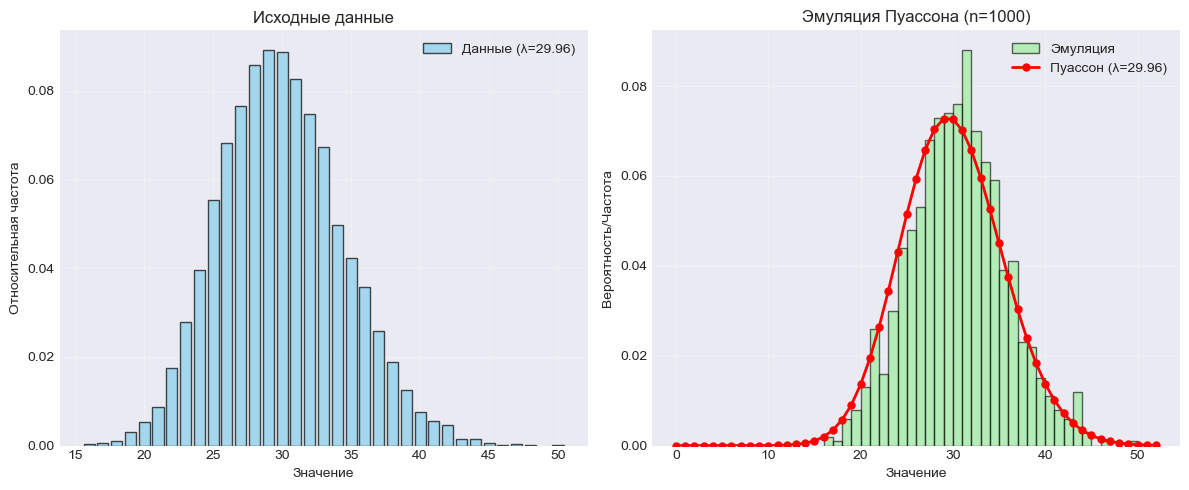


ПРОВЕРКА СООТВЕТСТВИЯ РАСПРЕДЕЛЕНИЮ ПУАССОНА
Отношение среднего к дисперсии: 1.493
⚠ Соотношение среднее ≈ дисперсия не выполняется

Тест Колмогорова-Смирнова:
  Статистика: 0.1105
  p-value: 0.0000
  ⚠ Гипотеза о распределении Пуассона отвергается (p ≤ 0.05)

Моделирование потока событий с λ=29.96:


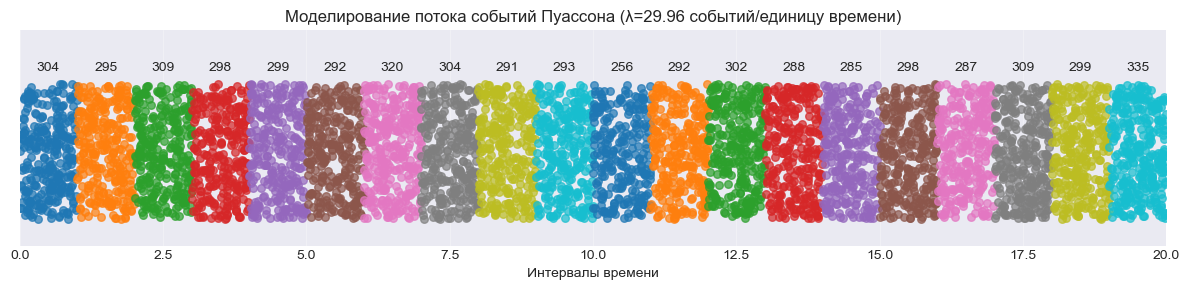

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Загрузка данных
df = pd.read_csv('data.csv')
print("Доступные колонки:", df.columns.tolist())

# 2. Выбор колонки для анализа (например, column_6)
data = df['column_3'].values  # Можно изменить на другую колонку

print(f"\nАнализ данных:")
print(f"Количество значений: {len(data)}")
print(f"Минимум: {np.min(data)}")
print(f"Максимум: {np.max(data)}")
print(f"Среднее: {np.mean(data):.2f}")
print(f"Дисперсия: {np.var(data):.2f}")

# 3. Оценка параметра λ (лямбда) для распределения Пуассона
# Для Пуассона λ = среднее = дисперсия
lambda_est = np.mean(data)
print(f"\nОценка параметра λ: {lambda_est:.4f}")

# 4. Эмуляция (генерация) данных по распределению Пуассона
n_simulations = 1000  # Количество симулированных значений
simulated_data = np.random.poisson(lam=lambda_est, size=n_simulations)

print(f"\nЭмуляция распределения Пуассона:")
print(f"Сгенерировано {n_simulations} значений")
print(f"Среднее сгенерированных: {np.mean(simulated_data):.2f}")
print(f"Дисперсия сгенерированных: {np.var(simulated_data):.2f}")

# 5. Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Исходные данные
unique_vals, counts = np.unique(data, return_counts=True)
probs_data = counts / len(data)

axes[0].bar(unique_vals, probs_data, alpha=0.7, color='skyblue', 
           edgecolor='black', label=f'Данные (λ={lambda_est:.2f})')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Относительная частота')
axes[0].set_title('Исходные данные')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Сгенерированные данные и теоретическое распределение
x_range = np.arange(0, max(np.max(data), np.max(simulated_data)) + 3)
pmf_poisson = stats.poisson.pmf(x_range, lambda_est)

# Гистограмма сгенерированных данных
axes[1].hist(simulated_data, bins=range(int(np.min(simulated_data)), 
            int(np.max(simulated_data)) + 2), density=True, 
            alpha=0.6, color='lightgreen', edgecolor='black',
            label='Эмуляция')

# Теоретическая PMF Пуассона
axes[1].plot(x_range, pmf_poisson, 'ro-', linewidth=2, markersize=5,
             label=f'Пуассон (λ={lambda_est:.2f})')

axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Вероятность/Частота')
axes[1].set_title(f'Эмуляция Пуассона (n={n_simulations})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Проверка соответствия распределению Пуассона
print("\n" + "="*50)
print("ПРОВЕРКА СООТВЕТСТВИЯ РАСПРЕДЕЛЕНИЮ ПУАССОНА")
print("="*50)

# Проверка условия: среднее ≈ дисперсия
mean_var_ratio = np.mean(data) / np.var(data)
print(f"Отношение среднего к дисперсии: {mean_var_ratio:.3f}")
if 0.8 < mean_var_ratio < 1.2:
    print("✓ Соотношение среднее ≈ дисперсия выполняется (характерно для Пуассона)")
else:
    print("⚠ Соотношение среднее ≈ дисперсия не выполняется")

# Тест Колмогорова-Смирнова
if len(data) > 30:  # Тест требует достаточного объема данных
    ks_stat, ks_p = stats.kstest(data, 'poisson', args=(lambda_est,))
    print(f"\nТест Колмогорова-Смирнова:")
    print(f"  Статистика: {ks_stat:.4f}")
    print(f"  p-value: {ks_p:.4f}")
    
    if ks_p > 0.05:
        print("  ✓ Гипотеза о распределении Пуассона не отвергается (p > 0.05)")
    else:
        print("  ⚠ Гипотеза о распределении Пуассона отвергается (p ≤ 0.05)")

# 7. Моделирование потока событий (альтернативная визуализация)
print(f"\nМоделирование потока событий с λ={lambda_est:.2f}:")
time_interval = 10  # временной интервал
events_in_interval = np.random.poisson(lam=lambda_est * time_interval, size=20)

fig, ax = plt.subplots(figsize=(12, 3))
for i, n_events in enumerate(events_in_interval):
    ax.scatter(np.random.uniform(i, i+1, n_events), 
               np.random.uniform(0, 1, n_events), 
               s=30, alpha=0.7)
    ax.text(i+0.5, 1.1, str(n_events), ha='center', fontsize=10)

ax.set_xlabel('Интервалы времени')
ax.set_title(f'Моделирование потока событий Пуассона (λ={lambda_est:.2f} событий/единицу времени)')
ax.set_yticks([])
ax.set_xlim([0, len(events_in_interval)])
ax.set_ylim([-0.2, 1.4])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

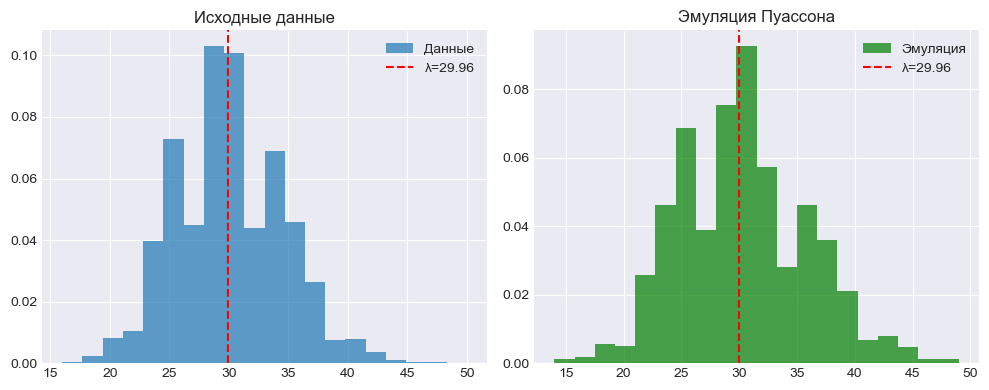

λ оценка: 29.9561
Сгенерировано 1000 значений


In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('data.csv')
data = df['column_3'].values  # Выберите нужную колонку

# Оценка λ и эмуляция
lambda_est = np.mean(data)
simulated = np.random.poisson(lambda_est, 1000)

# Быстрая визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(data, bins=20, alpha=0.7, density=True, label='Данные')
ax1.axvline(lambda_est, color='r', linestyle='--', label=f'λ={lambda_est:.2f}')
ax1.set_title('Исходные данные')
ax1.legend()

ax2.hist(simulated, bins=20, alpha=0.7, density=True, color='green', label='Эмуляция')
ax2.axvline(lambda_est, color='r', linestyle='--', label=f'λ={lambda_est:.2f}')
ax2.set_title('Эмуляция Пуассона')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"λ оценка: {lambda_est:.4f}")
print(f"Сгенерировано {len(simulated)} значений")

# Модуль 3. Интервальные оценки параметров распределения. Проверка гипотез